# Earthkit Africa Focus

Notebook de visualisation Earthkit avec une vue globe centrée sur l'Afrique, en conservant le logo et les informations de présentation sur l'image finale.

In [9]:
from pathlib import Path

import earthkit
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [10]:
temperature = earthkit.data.from_source(
    'cds',
    'derived-era5-pressure-levels-daily-statistics',
    {
        'product_type': 'reanalysis',
        'variable': ['temperature'],
        'year': '2026',
        'month': ['03'],
        'day': ['01'],
        'pressure_level': ['1000'],
        'daily_statistic': 'daily_mean',
        'time_zone': 'utc+00:00',
        'frequency': '1_hourly'
    },
)

datetime_for_plot = '2026-03-01 (UTC)'

2026-04-06 15:26:34,909 INFO Request ID is f3f19d3d-419a-420b-83cb-5e85505a1fd1
2026-04-06 15:26:35,006 INFO status has been updated to accepted
2026-04-06 15:26:59,603 INFO status has been updated to successful


In [11]:
temperature_style = earthkit.plots.styles.Style(
    colors='turbo',
    levels=range(-40, 41, 2),
    extend='both',
    units='celsius',
)

# Africa-focused projection with a cleaner continental emphasis than a globe view.
crs = ccrs.LambertAzimuthalEqualArea(central_longitude=20, central_latitude=5)

/tmp/ipykernel_115130/2404435938.py:11: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.16)


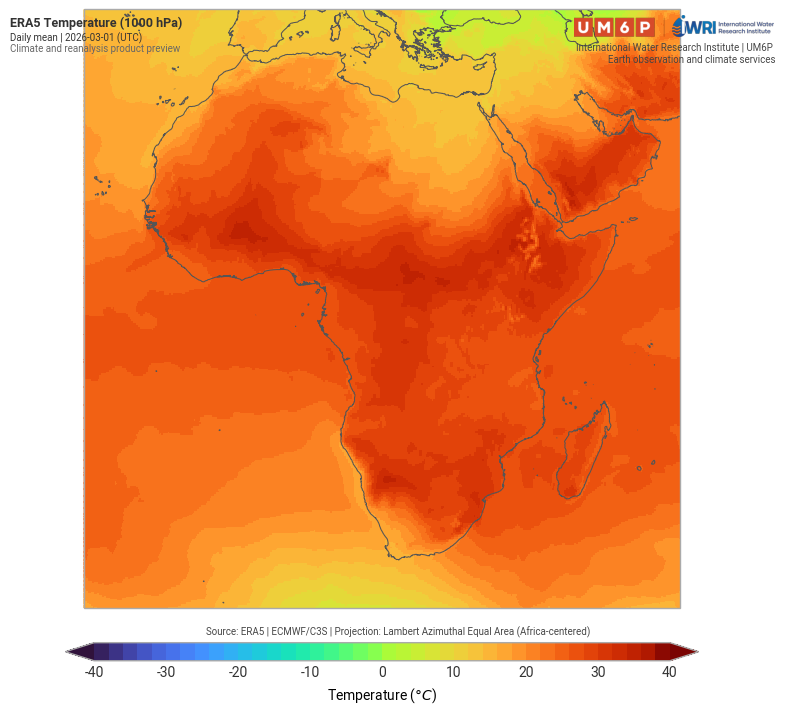

In [ ]:
earthkit.plots.schema.figsize = (9, 8.5)

chart = earthkit.plots.Map(crs=crs)
chart.pcolormesh(temperature, style=temperature_style)
chart.coastlines(resolution='high')
ax = plt.gca()
ax.set_extent([-25, 60, -40, 40], crs=ccrs.PlateCarree())
chart.legend(location='bottom')

fig = plt.gcf()
fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.16)


repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'c3s_atlas').exists() and (path / 'book').exists()
)
logo_path = repo_root / 'book' / 'customizing' / 'data' / 'logo' / 'logo-um6p-iwri-transparent.png'

fig.text(
    0.035,
    0.985,
    'ERA5 Temperature (1000 hPa)',
    fontsize=9,
    fontweight='bold',
    ha='left',
    va='top',
)
fig.text(
    0.035,
    0.962,
    f'Daily mean | {datetime_for_plot}',
    fontsize=7,
    ha='left',
    va='top',
)
fig.text(
    0.035,
    0.945,
    'Climate and reanalysis product preview',
    fontsize=7,
    color='#666666',
    ha='left',
    va='top',
)
fig.text(
    0.28,
    0.10,
    'Source: ERA5 | ECMWF/C3S | Projection: Lambert Azimuthal Equal Area (Africa-centered)',
    fontsize=7,
    color='#444444',
    ha='left',
)

if logo_path.exists():
    logo = mpimg.imread(logo_path)
    ax_logo = fig.add_axes([0.74, 0.925, 0.25, 0.09])
    ax_logo.imshow(logo)
    ax_logo.axis('off')

fig.text(
    0.988,
    0.948,
    'International Water Research Institute | UM6P',
    fontsize=7,
    color='#444444',
    ha='right',
    va='top',
)
fig.text(
    0.992,
    0.930,
    'Earth observation and climate services',
    fontsize=7,
    color='#444444',
    ha='right',
    va='top',
)

plt.savefig('overview-africa-focus.png', dpi=200, bbox_inches='tight')
plt.show()